<a href="https://colab.research.google.com/github/samar99-tech/arabic-AI-text-Detection/blob/main/notebooks/dataloadingcleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets pandas

In [ ]:
import datasets
print(datasets.__version__)

4.8.5


In [ ]:
#phase(1):Data Acquisition

In [ ]:
from datasets import load_dataset
# load datasets from Hugging Face
ds = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")
print(ds)

README.md:   0%|          | 0.00/8.10k [00:00<?, ?B/s]

data/by_polishing-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 8.49MB            

data/by_polishing-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/from_title-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.90MB            

data/from_title-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/from_title_and_content-00000-of-000(…): downloading bytes:           |  0.00B            

Generating by_polishing split:   0%|          | 0/2851 [00:00<?, ? examples/s]

Generating from_title split:   0%|          | 0/2963 [00:00<?, ? examples/s]

Generating from_title_and_content split:   0%|          | 0/2574 [00:00<?, ? examples/s]

DatasetDict({
    by_polishing: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2851
    })
    from_title: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2963
    })
    from_title_and_content: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2574
    })
})


In [ ]:
for subset in ds:
  print("="*50)
  print("subset:", subset)
  print("rows:", ds[subset].num_rows)
  print("columns", ds[subset].column_names)

subset: by_polishing
rows: 2851
columns ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
subset: from_title
rows: 2963
columns ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
subset: from_title_and_content
rows: 2574
columns ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']


  we have to first reshape from wide to long format.
  instead of 1 rows  = 5 texts reshape it into 1 row = 1 text and 1 label

In [ ]:
import pandas as pd
subsets = ["by_polishing", "from_title", "from_title_and_content"]
models =["allam", "jais", "llama", "openai"]
rows =[]
for split in subsets:
  for sample in ds[split]:
    if sample.get("original_abstract"):
      rows.append({
          "text": sample["original_abstract"],
          "label":0,
          "source": "human",
          "split": split
      })
    for model in models:
      col = f"{model}_generated_abstract"
      if sample.get(col):
        rows.append({
            "text": sample[col],
            "label":1,
            "source":model,
            "split": split
        })
df = pd.DataFrame(rows)
print(df.shape)
df.head()

(41940, 4)


,text,label,source,split
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,0,human,by_polishing
1,يتناول هذا البحث موضوع التعليم بين النساء الأن...,1,allam,by_polishing
2,تدرس هذه الدراسة دور المرأة في التعليم في الأن...,1,jais,by_polishing
3,يُقدم هذا البحث دراسة شاملة حول حالة التعليم ع...,1,llama,by_polishing
4,صور نظام التعليم عند المرأة الأندلسية تستند إل...,1,openai,by_polishing


now we have each row has a text with a label: human =0 / AI-generated =1

In [ ]:
print(df["label"].value_counts())

label
1    33552
0     8388
Name: count, dtype: int64


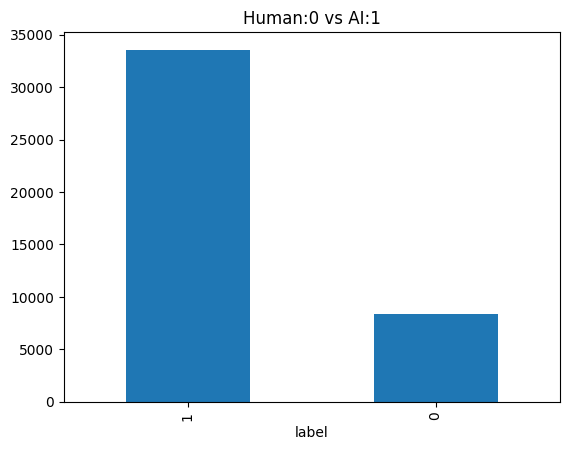

In [ ]:
import matplotlib.pyplot as plt
df["label"].value_counts().plot(
    kind="bar", title="Human:0 vs AI:1"
)
plt.show()



it shows unbalance between labels. around 8388 human
abstracts which is labeled 0 while 33552 Ai generated which is labeled 1

#data_quality: check missing data values, duplicatesn, and inconsistencies

In [ ]:
#frist keep a copy of raw data
df.to_csv("data_raw.csv", index=False , encoding="utf-8-sig")

In [ ]:
from google.colab import files
files.download("data_raw.csv")
#save a copy of raw dataset

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

inspect for any null values, duplicates, and blanks

In [ ]:
print("missing data: ",df.isnull().sum())
print("duplicates: ", df["text"].duplicated().sum())
print("blanks: ", df["text"].str.strip().eq("").sum())

missing data:  text      0
label     0
source    0
split     0
dtype: int64
duplicates:  5415
blanks:  0


no missing data or blank. only duplicates which are 5415 since the abstracts are shared in 3 subsets

In [ ]:
#clean data
df_clean = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
print("raw data: ",df.shape)
print("clean data: ",df_clean.shape)

raw data:  (41940, 4)
clean data:  (36541, 4)


the raw dataset: 41940
 created new clean set after removing  5399 duplicate rows based on text and label

In [ ]:
df_clean.to_csv("data_clean.csv", index=False, encoding="utf-8-sig")
files.download("data_clean.csv")
#save a copy of clean dataset

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>